In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from PIL import Image
from IPython.display import display
import sys
!{sys.executable} -m pip install scikit-learn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
all_tracts = pd.read_csv("NRI_Table_CensusTracts.csv")
state_tracts_wyoming = all_tracts[all_tracts["STATE"] == "Wyoming"]
state_tracts_wyoming

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
83054,83934,T56001962700,Wyoming,WY,56,Albany,County,1,56001,962700,...,98.098331,Very High,3.565698e-06,9.074709e-07,2.465977e-07,44.970463,43176.112906,97.356912,Very High,December 2025
83055,83935,T56001962800,Wyoming,WY,56,Albany,County,1,56001,962800,...,97.597025,Very High,3.441690e-06,8.669193e-07,2.465875e-07,32.389560,41049.556148,97.131690,Very High,December 2025
83056,83936,T56001962900,Wyoming,WY,56,Albany,County,1,56001,962900,...,93.905481,Relatively High,3.441690e-06,8.669193e-07,2.465939e-07,42.618089,19907.740506,91.392686,Relatively High,December 2025
83057,83937,T56001963000,Wyoming,WY,56,Albany,County,1,56001,963000,...,96.599120,Very High,3.441689e-06,8.669193e-07,0.000000e+00,63.149286,28274.778785,94.897339,Relatively High,December 2025
83058,83938,T56001963101,Wyoming,WY,56,Albany,County,1,56001,963101,...,98.101862,Very High,3.475756e-06,8.785324e-07,0.000000e+00,34.952576,41406.100462,97.167439,Very High,December 2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83209,84089,T56043000200,Wyoming,WY,56,Washakie,County,43,56043,200,...,82.850856,Relatively High,5.791038e-07,2.285392e-07,3.544090e-08,29.245216,14964.443232,87.269564,Relatively High,December 2025
83210,84090,T56043000301,Wyoming,WY,56,Washakie,County,43,56043,301,...,75.127680,Relatively Moderate,5.063479e-07,2.137761e-07,0.000000e+00,24.808774,9268.241032,78.104556,Relatively Moderate,December 2025
83211,84091,T56043000302,Wyoming,WY,56,Washakie,County,43,56043,302,...,73.977971,Relatively Moderate,5.063479e-07,2.137761e-07,3.276360e-08,25.970251,10587.229212,80.898984,Relatively High,December 2025
83212,84092,T56045951100,Wyoming,WY,56,Weston,County,45,56045,951100,...,98.063028,Very High,2.165025e-05,5.089602e-07,2.080879e-07,87.366142,43709.156622,97.428411,Very High,December 2025


In [4]:
state_tracts_illinois = all_tracts[all_tracts["STATE"] == "Illinois"]
state_tracts_illinois

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
24014,24894,T17001000100,Illinois,IL,17,Adams,County,1,17001,100,...,76.428017,Relatively Moderate,6.123300e-07,1.113262e-07,0.000003,32.440161,9103.980995,77.725610,Relatively Moderate,December 2025
24015,24895,T17001000201,Illinois,IL,17,Adams,County,1,17001,201,...,56.834710,Relatively Moderate,6.123301e-07,1.113262e-07,0.000003,26.399774,3271.765665,53.183503,Relatively Moderate,December 2025
24016,24896,T17001000202,Illinois,IL,17,Adams,County,1,17001,202,...,64.849726,Relatively Moderate,6.123300e-07,1.113262e-07,0.000000,28.168467,4944.285398,63.117128,Relatively Moderate,December 2025
24017,24897,T17001000400,Illinois,IL,17,Adams,County,1,17001,400,...,71.243145,Relatively Moderate,6.123301e-07,1.113262e-07,0.000003,26.624538,8681.022129,76.661463,Relatively Moderate,December 2025
24018,24898,T17001000500,Illinois,IL,17,Adams,County,1,17001,500,...,52.934877,Relatively Moderate,6.123301e-07,1.113262e-07,0.000000,29.444091,3039.610596,51.448455,Relatively Moderate,December 2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27272,28152,T17203030501,Illinois,IL,17,Woodford,County,203,17203,30501,...,86.858952,Relatively High,1.175636e-06,9.538822e-08,0.000004,62.141966,11305.002707,82.201461,Relatively High,December 2025
27273,28153,T17203030502,Illinois,IL,17,Woodford,County,203,17203,30502,...,60.542729,Relatively Moderate,1.175636e-06,9.538822e-08,0.000004,60.661583,4344.762170,60.025978,Relatively Moderate,December 2025
27274,28154,T17203030601,Illinois,IL,17,Woodford,County,203,17203,30601,...,82.679046,Relatively High,1.175635e-06,9.538820e-08,0.000004,61.166420,12570.506284,84.203439,Relatively High,December 2025
27275,28155,T17203030602,Illinois,IL,17,Woodford,County,203,17203,30602,...,72.675281,Relatively Moderate,1.175636e-06,9.538822e-08,0.000004,69.335593,4026.139146,58.175340,Relatively Moderate,December 2025


In [5]:
wy_svi = pd.read_csv("Wyoming.csv")
wy_nri = pd.read_csv("state_tracts_wyoming.csv")
il_svi = pd.read_csv("Illinois.csv")
il_nri = pd.read_csv("state_tracts_illinois.csv")

In [6]:
wy_svi.describe()

,ST,STCNTY,FIPS,AREA_SQMI,E_TOTPOP,M_TOTPOP,E_HU,M_HU,E_HH,M_HH,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
count,160.0,160.00000,1.600000e+02,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,...,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000
mean,56.0,56022.06250,5.602258e+10,606.804447,3612.056250,464.418750,1708.068750,182.825000,1463.475000,188.475000,...,-5.479375,-4.923125,-4.388125,-4.905625,-6.150000,-5.077500,-3.180000,-3.859375,-5.815000,-4.885000
std,0.0,12.23033,1.224556e+07,1141.592670,1418.058919,183.595346,583.098869,60.292114,558.124735,63.831731,...,79.051319,79.088484,79.475421,79.096528,78.985955,79.072642,79.255351,79.181993,79.017274,79.095126
min,56.0,56001.00000,5.600196e+10,0.480469,0.000000,0.000000,0.000000,13.000000,0.000000,13.000000,...,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000
25%,56.0,56013.00000,5.601371e+10,2.287053,2589.000000,336.750000,1300.250000,137.750000,1077.250000,141.000000,...,0.000000,0.700000,0.000000,0.500000,0.000000,0.800000,1.500000,1.400000,0.000000,0.700000
50%,56.0,56021.00000,5.602100e+10,13.121187,3396.000000,441.500000,1668.500000,177.500000,1404.000000,183.000000,...,0.250000,1.100000,0.300000,1.100000,0.000000,1.100000,2.600000,2.100000,0.000000,1.100000
75%,56.0,56033.00000,5.603300e+10,885.603189,4552.250000,563.250000,2134.500000,221.000000,1833.250000,229.000000,...,0.900000,1.700000,1.225000,1.700000,0.000000,1.400000,4.025000,3.025000,0.400000,1.500000
max,56.0,56045.00000,5.604595e+10,8176.173826,8019.000000,991.000000,3411.000000,334.000000,3215.000000,359.000000,...,11.400000,5.600000,78.900000,12.600000,2.000000,3.400000,14.400000,11.600000,4.700000,7.000000


In [7]:
il_svi.describe()

,ST,STCNTY,FIPS,AREA_SQMI,E_TOTPOP,M_TOTPOP,E_HU,M_HU,E_HH,M_HH,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
count,3263.0,3263.000000,3.263000e+03,3263.000000,3263.000000,3263.000000,3263.000000,3263.000000,3263.000000,3263.000000,...,3263.000000,3263.000000,3263.000000,3263.000000,3263.000000,3263.000000,3263.000000,3263.000000,3263.000000,3263.000000
mean,17.0,17079.223108,1.707978e+10,17.012924,3909.786699,500.833589,1663.302789,180.278272,1522.758504,183.073245,...,3.909746,1.643518,-1.144591,-0.200031,-1.199755,-0.114618,1.522188,1.165461,-0.914527,0.020074
std,0.0,59.924880,5.987920e+07,42.743769,1644.749956,240.484207,709.614668,78.100717,670.755609,79.548287,...,36.135208,35.194915,34.965350,35.046497,34.962633,35.048665,35.144682,35.133030,34.982728,35.063731
min,17.0,17001.000000,1.700100e+10,0.008555,0.000000,5.000000,0.000000,5.000000,0.000000,5.000000,...,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000
25%,17.0,17031.000000,1.703173e+10,0.434882,2686.500000,332.000000,1183.000000,128.000000,1063.500000,129.000000,...,0.100000,1.000000,0.000000,0.600000,0.000000,0.700000,1.000000,1.200000,0.000000,0.700000
50%,17.0,17043.000000,1.704384e+10,1.188840,3757.000000,458.000000,1584.000000,167.000000,1455.000000,169.000000,...,1.600000,1.900000,0.000000,0.900000,0.000000,0.900000,2.200000,1.900000,0.000000,0.900000
75%,17.0,17117.000000,1.711796e+10,4.730917,4897.500000,618.000000,2033.500000,219.000000,1888.500000,222.000000,...,6.100000,4.000000,0.000000,1.200000,0.000000,1.300000,3.800000,3.000000,0.300000,1.400000
max,17.0,17203.000000,1.720303e+10,299.521779,12213.000000,2077.000000,7957.000000,759.000000,7384.000000,819.000000,...,81.000000,100.000000,7.600000,100.000000,3.700000,100.000000,19.600000,100.000000,14.400000,100.000000


In [8]:
print(wy_svi.isnull().sum())

ST              0
STATE           0
ST_ABBR         0
STCNTY          0
COUNTY          0
               ..
MP_NHPI         0
EP_TWOMORE      0
MP_TWOMORE      0
EP_OTHERRACE    0
MP_OTHERRACE    0
Length: 158, dtype: int64


In [9]:
print(il_svi.isnull().sum())

ST              0
STATE           0
ST_ABBR         0
STCNTY          0
COUNTY          0
               ..
MP_NHPI         0
EP_TWOMORE      0
MP_TWOMORE      0
EP_OTHERRACE    0
MP_OTHERRACE    0
Length: 158, dtype: int64


In [10]:
wy_nri['STCNTY'] = wy_nri['STCOFIPS']
wy_nri.columns

Index(['Unnamed: 0', 'OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS',
       'COUNTY', 'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS',
       ...
       'WNTW_EALR', 'WNTW_ALRB', 'WNTW_ALRP', 'WNTW_ALRA', 'WNTW_ALR_NPCTL',
       'WNTW_RISKV', 'WNTW_RISKS', 'WNTW_RISKR', 'NRI_VER', 'STCNTY'],
      dtype='object', length=469)

In [11]:
il_nri['STCNTY'] = il_nri['STCOFIPS']
il_nri.columns

Index(['Unnamed: 0', 'OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS',
       'COUNTY', 'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS',
       ...
       'WNTW_EALR', 'WNTW_ALRB', 'WNTW_ALRP', 'WNTW_ALRA', 'WNTW_ALR_NPCTL',
       'WNTW_RISKV', 'WNTW_RISKS', 'WNTW_RISKR', 'NRI_VER', 'STCNTY'],
      dtype='object', length=469)

In [12]:
complete_data_wyoming = pd.merge(wy_nri, wy_svi, on = 'STCNTY',  suffixes=('', '_right'))

In [13]:
complete_data_illinois = pd.merge(il_nri, il_svi, on = 'STCNTY', suffixes=('', '_right'))

In [14]:
complete_data_wyoming.columns

Index(['Unnamed: 0', 'OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS',
       'COUNTY', 'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=626)

In [15]:
complete_data_illinois.columns

Index(['Unnamed: 0', 'OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS',
       'COUNTY', 'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=626)

In [16]:
complete_data_wyoming['wy_risk_1'] = complete_data_wyoming['HWAV_AFREQ']*complete_data_wyoming['HWAV_EXPA']
print(complete_data_wyoming['wy_risk_1'], complete_data_wyoming['HWAV_AFREQ'], complete_data_wyoming['HWAV_EXPA'])


0       0.000000e+00
1       0.000000e+00
2       0.000000e+00
3       0.000000e+00
4       0.000000e+00
            ...     
1981    4.086275e+05
1982    3.168734e+06
1983    3.168734e+06
1984    2.822774e+05
1985    2.822774e+05
Name: wy_risk_1, Length: 1986, dtype: float64 0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.000000
          ...   
1981    0.315789
1982    0.198570
1983    0.198570
1984    0.263158
1985    0.263158
Name: HWAV_AFREQ, Length: 1986, dtype: float64 0       0.000000e+00
1       0.000000e+00
2       0.000000e+00
3       0.000000e+00
4       0.000000e+00
            ...     
1981    1.293987e+06
1982    1.595777e+07
1983    1.595777e+07
1984    1.072654e+06
1985    1.072654e+06
Name: HWAV_EXPA, Length: 1986, dtype: float64


In [17]:
complete_data_illinois['il_risk_1'] = complete_data_illinois['HWAV_AFREQ']*complete_data_illinois['HWAV_EXPA']
print(complete_data_illinois['il_risk_1'], complete_data_illinois['HWAV_AFREQ'], complete_data_illinois['HWAV_EXPA'])

0          8.099949e+06
1          8.099949e+06
2          8.099949e+06
3          8.099949e+06
4          8.099949e+06
               ...     
1926936    3.249960e+08
1926937    3.249960e+08
1926938    3.249960e+08
1926939    3.249960e+08
1926940    3.249960e+08
Name: il_risk_1, Length: 1926941, dtype: float64 0          8.421053
1          8.421053
2          8.421053
3          8.421053
4          8.421053
             ...   
1926936    6.526316
1926937    6.526316
1926938    6.526316
1926939    6.526316
1926940    6.526316
Name: HWAV_AFREQ, Length: 1926941, dtype: float64 0            961869.0
1            961869.0
2            961869.0
3            961869.0
4            961869.0
              ...    
1926936    49797779.0
1926937    49797779.0
1926938    49797779.0
1926939    49797779.0
1926940    49797779.0
Name: HWAV_EXPA, Length: 1926941, dtype: float64


In [18]:
complete_data_wyoming['hail_risk_wy'] = complete_data_wyoming['HAIL_RISKS']*complete_data_wyoming['HAIL_RISKS']

print(complete_data_wyoming)

      Unnamed: 0   OID_        NRI_ID    STATE STATEABBRV  STATEFIPS  \
0          83054  83934  T56001962700  Wyoming         WY         56   
1          83054  83934  T56001962700  Wyoming         WY         56   
2          83054  83934  T56001962700  Wyoming         WY         56   
3          83054  83934  T56001962700  Wyoming         WY         56   
4          83054  83934  T56001962700  Wyoming         WY         56   
...          ...    ...           ...      ...        ...        ...   
1981       83211  84091  T56043000302  Wyoming         WY         56   
1982       83212  84092  T56045951100  Wyoming         WY         56   
1983       83212  84092  T56045951100  Wyoming         WY         56   
1984       83213  84093  T56045951300  Wyoming         WY         56   
1985       83213  84093  T56045951300  Wyoming         WY         56   

        COUNTY COUNTYTYPE  COUNTYFIPS  STCOFIPS  ...  EP_AIAN  MP_AIAN  \
0       Albany     County           1     56001  ...      0.0

In [19]:
complete_data_illinois['hail_risk_il'] = complete_data_illinois['HAIL_RISKS']*complete_data_illinois['HAIL_RISKS']

print(complete_data_illinois)

         Unnamed: 0   OID_        NRI_ID     STATE STATEABBRV  STATEFIPS  \
0             24014  24894  T17001000100  Illinois         IL         17   
1             24014  24894  T17001000100  Illinois         IL         17   
2             24014  24894  T17001000100  Illinois         IL         17   
3             24014  24894  T17001000100  Illinois         IL         17   
4             24014  24894  T17001000100  Illinois         IL         17   
...             ...    ...           ...       ...        ...        ...   
1926936       27276  28156  T17203030700  Illinois         IL         17   
1926937       27276  28156  T17203030700  Illinois         IL         17   
1926938       27276  28156  T17203030700  Illinois         IL         17   
1926939       27276  28156  T17203030700  Illinois         IL         17   
1926940       27276  28156  T17203030700  Illinois         IL         17   

           COUNTY COUNTYTYPE  COUNTYFIPS  STCOFIPS  ...  EP_AIAN  MP_AIAN  \
0         

In [20]:
complete_data_wyoming['ice_storm_risk_wy'] = complete_data_wyoming['ISTM_AFREQ']*complete_data_wyoming['ISTM_EXPB']
complete_data_wyoming['tornado_risk_wy'] = complete_data_wyoming['TRND_AFREQ']*complete_data_wyoming['TRND_EXPA']

complete_data_wyoming['combined_risk_wy'] = complete_data_wyoming['ice_storm_risk_wy'] + complete_data_wyoming['tornado_risk_wy']
print(complete_data_wyoming[['ice_storm_risk_wy', 'tornado_risk_wy', 'combined_risk_wy']].head())

   ice_storm_risk_wy  tornado_risk_wy  combined_risk_wy
0       2.922128e+07    947136.632181      3.016842e+07
1       2.922128e+07    947136.632181      3.016842e+07
2       2.922128e+07    947136.632181      3.016842e+07
3       2.922128e+07    947136.632181      3.016842e+07
4       2.922128e+07    947136.632181      3.016842e+07


In [21]:
complete_data_illinois['ice_storm_risk_il'] = complete_data_illinois['ISTM_AFREQ']*complete_data_illinois['ISTM_EXPB']
complete_data_illinois['tornado_risk_il'] = complete_data_illinois['TRND_AFREQ']*complete_data_illinois['TRND_EXPA']

complete_data_illinois['combined_risk_il'] = complete_data_illinois['ice_storm_risk_il'] + complete_data_illinois['tornado_risk_il']
print(complete_data_illinois[['ice_storm_risk_il', 'tornado_risk_il', 'combined_risk_il']].head())

   ice_storm_risk_il  tornado_risk_il  combined_risk_il
0       1.277281e+09      3367.636692      1.277284e+09
1       1.277281e+09      3367.636692      1.277284e+09
2       1.277281e+09      3367.636692      1.277284e+09
3       1.277281e+09      3367.636692      1.277284e+09
4       1.277281e+09      3367.636692      1.277284e+09


             mean_ice_storm_wy  mean_tornado_wy
COUNTY                                         
Albany            2.649875e+07     3.471606e+06
Big Horn          1.740913e+07     2.555612e+06
Campbell          1.621457e+07     1.618224e+06
Carbon            1.278331e+07     1.929456e+06
Converse          1.578878e+07     1.195635e+07
Crook             1.965179e+07     1.080477e+07
Fremont           1.203920e+07     3.429923e+05
Goshen            2.655875e+07     3.687571e+07
Hot Springs       1.089974e+07     1.215285e+06
Johnson           1.311625e+07     8.744579e+06
Laramie           2.332744e+07     3.684725e+06
Lincoln           1.888350e+07     8.339914e+05
Natrona           1.384745e+07     5.820213e+05
Niobrara          1.231435e+07     3.929235e+07
Park              1.671388e+07     1.144974e+06
Platte            2.383252e+07     9.919466e+06
Sheridan          1.615406e+07     9.845676e+05
Sublette          1.903880e+07     1.299511e+06
Sweetwater        1.227111e+07     3.241

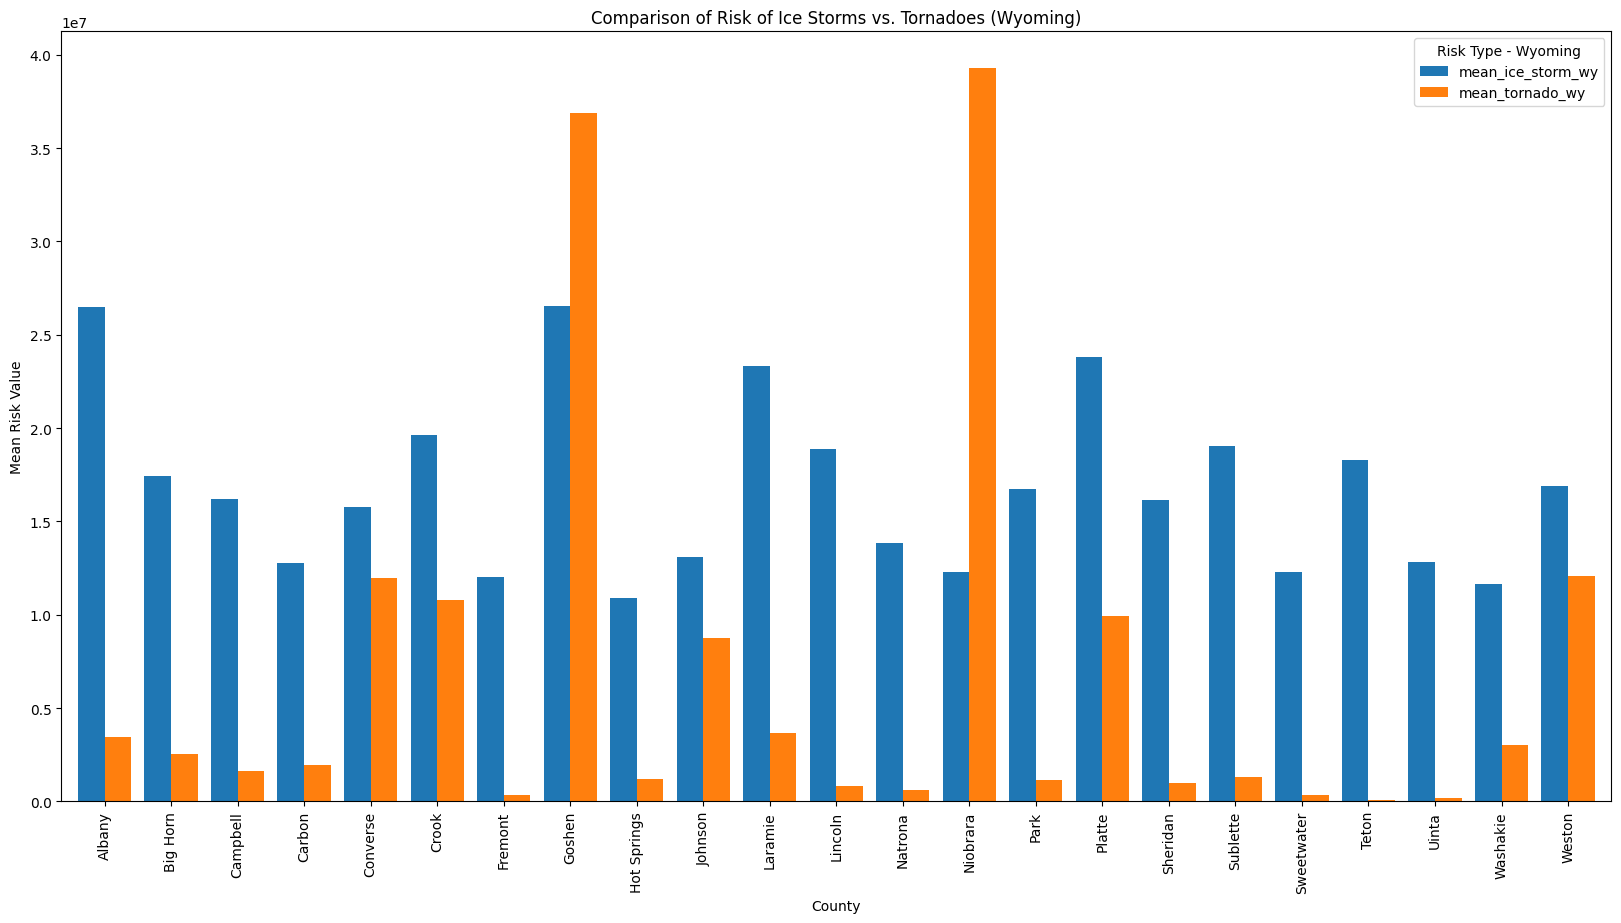

In [22]:
grouped_data_wyoming = complete_data_wyoming.groupby('COUNTY').agg(
    mean_ice_storm_wy=('ice_storm_risk_wy', 'mean'),
    mean_tornado_wy=('tornado_risk_wy', 'mean')
)
print(grouped_data_wyoming)
grouped_data_wyoming.plot(kind='bar', figsize=(20, 10), width=0.8)
plt.xlabel('County')
plt.ylabel('Mean Risk Value')
plt.title('Comparison of Risk of Ice Storms vs. Tornadoes (Wyoming)')
plt.xticks(rotation=90)
plt.legend(title="Risk Type - Wyoming")
plt.show()

            mean_ice_storm_il  mean_tornado_il
COUNTY                                        
Adams            5.786272e+08     1.877683e+06
Alexander        4.892060e+08     4.832084e+05
Bond             1.226518e+09     3.362773e+06
Boone            9.564596e+08     6.095755e+05
Brown            5.943460e+08     7.237973e+06
...                       ...              ...
Whiteside        4.608757e+08     1.842601e+06
Will             1.150414e+09     2.198559e+04
Williamson       7.251566e+08     1.255613e+05
Winnebago        6.174105e+08     8.882881e+04
Woodford         1.571497e+09     2.388690e+06

[102 rows x 2 columns]


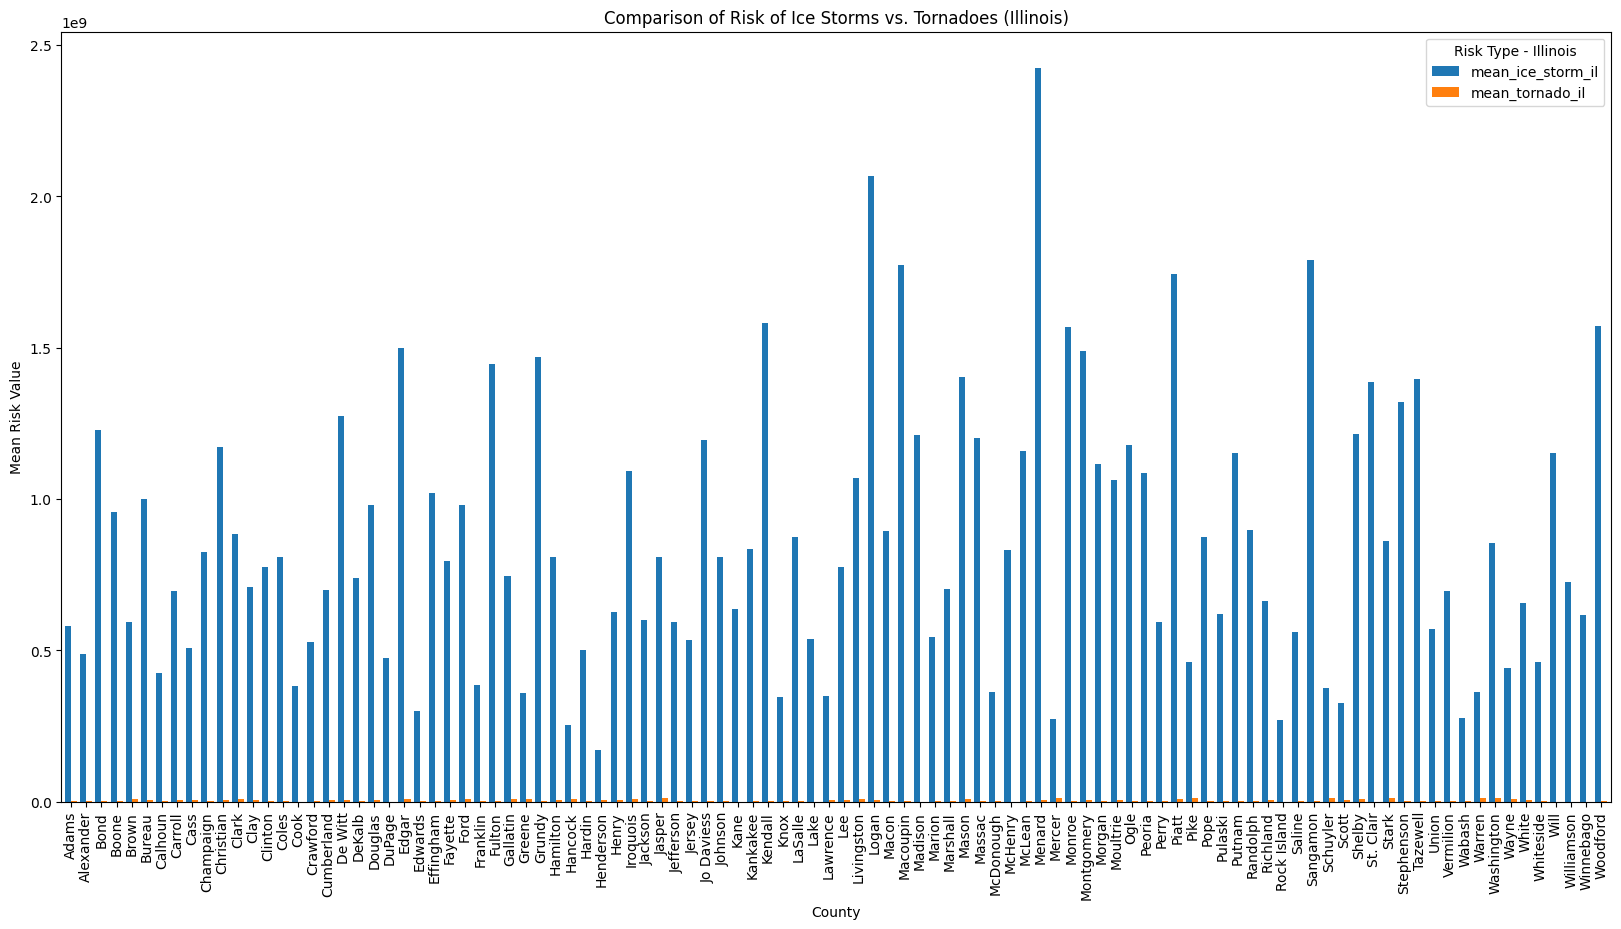

In [23]:
grouped_data_illinois = complete_data_illinois.groupby('COUNTY').agg(
    mean_ice_storm_il=('ice_storm_risk_il', 'mean'),
    mean_tornado_il=('tornado_risk_il', 'mean')
)
print(grouped_data_illinois)
grouped_data_illinois.plot(kind='bar', figsize=(20, 10), width=0.8)
plt.xlabel('County')
plt.ylabel('Mean Risk Value')
plt.title('Comparison of Risk of Ice Storms vs. Tornadoes (Illinois)')
plt.xticks(rotation=90)
plt.legend(title="Risk Type - Illinois")
plt.show()

In [24]:
data = {'col1': [1, 2, np.nan, 4], 'col2': [5, np.nan, 7, 8]}
df = pd.DataFrame(data)
print(df.isna())

    col1   col2
0  False  False
1  False   True
2   True  False
3  False  False


In [25]:
wy_nri = pd.read_csv("state_tracts_wyoming.csv")
wy_nri = pd.DataFrame(wy_nri)
print(wy_nri.isna())

     Unnamed: 0   OID_  NRI_ID  STATE  STATEABBRV  STATEFIPS  COUNTY  \
0         False  False   False  False       False      False   False   
1         False  False   False  False       False      False   False   
2         False  False   False  False       False      False   False   
3         False  False   False  False       False      False   False   
4         False  False   False  False       False      False   False   
..          ...    ...     ...    ...         ...        ...     ...   
155       False  False   False  False       False      False   False   
156       False  False   False  False       False      False   False   
157       False  False   False  False       False      False   False   
158       False  False   False  False       False      False   False   
159       False  False   False  False       False      False   False   

     COUNTYTYPE  COUNTYFIPS  STCOFIPS  ...  WNTW_EALS  WNTW_EALR  WNTW_ALRB  \
0         False       False     False  ...      False   

In [26]:
il_nri = pd.read_csv("state_tracts_illinois.csv")
il_nri = pd.DataFrame(il_nri)
print(il_nri.isna())

      Unnamed: 0   OID_  NRI_ID  STATE  STATEABBRV  STATEFIPS  COUNTY  \
0          False  False   False  False       False      False   False   
1          False  False   False  False       False      False   False   
2          False  False   False  False       False      False   False   
3          False  False   False  False       False      False   False   
4          False  False   False  False       False      False   False   
...          ...    ...     ...    ...         ...        ...     ...   
3258       False  False   False  False       False      False   False   
3259       False  False   False  False       False      False   False   
3260       False  False   False  False       False      False   False   
3261       False  False   False  False       False      False   False   
3262       False  False   False  False       False      False   False   

      COUNTYTYPE  COUNTYFIPS  STCOFIPS  ...  WNTW_EALS  WNTW_EALR  WNTW_ALRB  \
0          False       False     False  ...

In [27]:
df_dropped = df.dropna() 
df_dropped_cols = df.dropna(axis=1) 

In [28]:
wy_nri_dropped = wy_nri.dropna()
wy_nri_dropped_columns = wy_nri.dropna(axis = 1)
print(wy_nri_dropped_columns)

     Unnamed: 0   OID_        NRI_ID    STATE STATEABBRV  STATEFIPS    COUNTY  \
0         83054  83934  T56001962700  Wyoming         WY         56    Albany   
1         83055  83935  T56001962800  Wyoming         WY         56    Albany   
2         83056  83936  T56001962900  Wyoming         WY         56    Albany   
3         83057  83937  T56001963000  Wyoming         WY         56    Albany   
4         83058  83938  T56001963101  Wyoming         WY         56    Albany   
..          ...    ...           ...      ...        ...        ...       ...   
155       83209  84089  T56043000200  Wyoming         WY         56  Washakie   
156       83210  84090  T56043000301  Wyoming         WY         56  Washakie   
157       83211  84091  T56043000302  Wyoming         WY         56  Washakie   
158       83212  84092  T56045951100  Wyoming         WY         56    Weston   
159       83213  84093  T56045951300  Wyoming         WY         56    Weston   

    COUNTYTYPE  COUNTYFIPS 

In [29]:
il_nri_dropped = il_nri.dropna()
il_nri_dropped_columns = il_nri.dropna(axis = 1)
print(il_nri_dropped_columns)

      Unnamed: 0   OID_        NRI_ID     STATE STATEABBRV  STATEFIPS  \
0          24014  24894  T17001000100  Illinois         IL         17   
1          24015  24895  T17001000201  Illinois         IL         17   
2          24016  24896  T17001000202  Illinois         IL         17   
3          24017  24897  T17001000400  Illinois         IL         17   
4          24018  24898  T17001000500  Illinois         IL         17   
...          ...    ...           ...       ...        ...        ...   
3258       27272  28152  T17203030501  Illinois         IL         17   
3259       27273  28153  T17203030502  Illinois         IL         17   
3260       27274  28154  T17203030601  Illinois         IL         17   
3261       27275  28155  T17203030602  Illinois         IL         17   
3262       27276  28156  T17203030700  Illinois         IL         17   

        COUNTY COUNTYTYPE  COUNTYFIPS  STCOFIPS  ...  WNTW_EALS  \
0        Adams     County           1     17001  ...  76

In [30]:
df_filled_0 = df.fillna(0)
df_filled_mean = df.fillna(df.mean())
print(df_filled_mean)

       col1      col2
0  1.000000  5.000000
1  2.000000  6.666667
2  2.333333  7.000000
3  4.000000  8.000000


In [31]:
wy_nri_filled_0 = wy_nri.fillna(0)
wy_nri_filled_min = wy_nri.fillna(wy_nri.min())
wy_nri_filled_min.head(2)

,Unnamed: 0,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
0,83054,83934,T56001962700,Wyoming,WY,56,Albany,County,1,56001,...,98.098331,Very High,0.000004,9.074709e-07,2.465977e-07,44.970463,43176.112906,97.356912,Very High,December 2025
1,83055,83935,T56001962800,Wyoming,WY,56,Albany,County,1,56001,...,97.597025,Very High,0.000003,8.669193e-07,2.465875e-07,32.389560,41049.556148,97.131690,Very High,December 2025


In [32]:
il_nri_filled_0 = il_nri.fillna(0)
il_nri_filled_min = il_nri.fillna(il_nri.min())
il_nri_filled_min.head(2)

,Unnamed: 0,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
0,24014,24894,T17001000100,Illinois,IL,17,Adams,County,1,17001,...,76.428017,Relatively Moderate,6.123300e-07,1.113262e-07,0.000003,32.440161,9103.980995,77.725610,Relatively Moderate,December 2025
1,24015,24895,T17001000201,Illinois,IL,17,Adams,County,1,17001,...,56.834710,Relatively Moderate,6.123301e-07,1.113262e-07,0.000003,26.399774,3271.765665,53.183503,Relatively Moderate,December 2025


In [33]:
print(df)
df_interpolated = df.interpolate()
print(df_interpolated)

   col1  col2
0   1.0   5.0
1   2.0   NaN
2   NaN   7.0
3   4.0   8.0
   col1  col2
0   1.0   5.0
1   2.0   6.0
2   3.0   7.0
3   4.0   8.0


In [34]:
wy_nri_interpolated = wy_nri.interpolate()

C:\Users\Rebecca\AppData\Local\Temp\ipykernel_21128\1976272185.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  wy_nri_interpolated = wy_nri.interpolate()


In [35]:
il_nri_interpolated = il_nri.interpolate()

C:\Users\Rebecca\AppData\Local\Temp\ipykernel_21128\56124941.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  il_nri_interpolated = il_nri.interpolate()


In [36]:
x = 10
y = 3.14
z = "hello"
a = float(x)
print(a) 
print(type(a)) 

b = int(y)
print(b)  
print(type(b)) 

c = str(x)
print(c) 
print(type(c)) 
d = int("123")
print(d) 
print(type(d))
e = float("3.14")
print(e) 
print(type(e))
f = bool(x)
print(f) 
print(type(f))
g = tuple([1, 2, 3])
print(g)
print(type(g))

10.0
<class 'float'>
3
<class 'int'>
10
<class 'str'>
123
<class 'int'>
3.14
<class 'float'>
True
<class 'bool'>
(1, 2, 3)
<class 'tuple'>


In [37]:
print(wy_nri.dtypes)
wy_nri['WNTW_EALR'== wy_nri['WNTW_EALR'].astype(str)]
wy_nri['STATE'== wy_nri['STATE'].astype(str)]
print(wy_nri.dtypes)

Unnamed: 0          int64
OID_                int64
NRI_ID             object
STATE              object
STATEABBRV         object
                   ...   
WNTW_ALR_NPCTL    float64
WNTW_RISKV        float64
WNTW_RISKS        float64
WNTW_RISKR         object
NRI_VER            object
Length: 468, dtype: object
Unnamed: 0          int64
OID_                int64
NRI_ID             object
STATE              object
STATEABBRV         object
                   ...   
WNTW_ALR_NPCTL    float64
WNTW_RISKV        float64
WNTW_RISKS        float64
WNTW_RISKR         object
NRI_VER            object
Length: 468, dtype: object


In [38]:
print(il_nri.dtypes)
il_nri['WNTW_EALR'== il_nri['WNTW_EALR'].astype(str)]
il_nri['STATE'== il_nri['STATE'].astype(str)]
print(il_nri.dtypes)

Unnamed: 0          int64
OID_                int64
NRI_ID             object
STATE              object
STATEABBRV         object
                   ...   
WNTW_ALR_NPCTL    float64
WNTW_RISKV        float64
WNTW_RISKS        float64
WNTW_RISKR         object
NRI_VER            object
Length: 468, dtype: object
Unnamed: 0          int64
OID_                int64
NRI_ID             object
STATE              object
STATEABBRV         object
                   ...   
WNTW_ALR_NPCTL    float64
WNTW_RISKV        float64
WNTW_RISKS        float64
WNTW_RISKR         object
NRI_VER            object
Length: 468, dtype: object


In [39]:
data = {
    "Soil_Moisture": [23.5, 45.1, np.nan, 37.8, 29.2, np.nan, 41.0],
    "Land_Use": pd.Series(["Urban", "Agriculture", "Urban", np.nan, "Forest", "Urban", np.nan], dtype="category"),
    "Slope": [5.1, 3.2, 4.7, 6.3, 2.9, 3.5, 4.1]
}
toy_df = pd.DataFrame(data)

In [40]:
print("Original dataset:")
print(toy_df)

Original dataset:
   Soil_Moisture     Land_Use  Slope
0           23.5        Urban    5.1
1           45.1  Agriculture    3.2
2            NaN        Urban    4.7
3           37.8          NaN    6.3
4           29.2       Forest    2.9
5            NaN        Urban    3.5
6           41.0          NaN    4.1


In [41]:
print(toy_df)
missing = toy_df.isnull().sum()
print(missing)

   Soil_Moisture     Land_Use  Slope
0           23.5        Urban    5.1
1           45.1  Agriculture    3.2
2            NaN        Urban    4.7
3           37.8          NaN    6.3
4           29.2       Forest    2.9
5            NaN        Urban    3.5
6           41.0          NaN    4.1
Soil_Moisture    2
Land_Use         2
Slope            0
dtype: int64


In [42]:
missing.to_csv('missing_values_summary.csv', header = ['MissingCount'])

<Axes: xlabel='Soil_Moisture', ylabel='Count'>

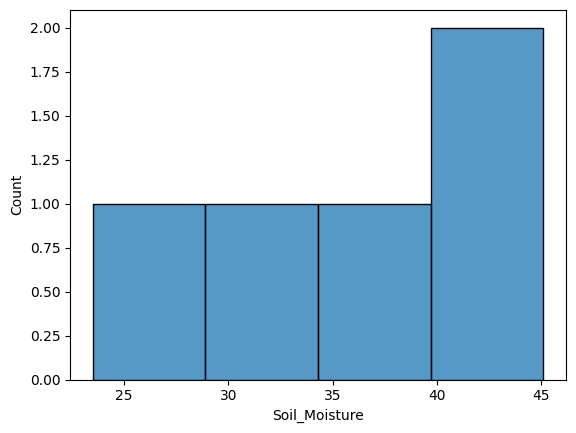

In [43]:
sns.histplot(toy_df["Soil_Moisture"])

In [44]:
mean_imputed = toy_df['Soil_Moisture'].fillna(toy_df['Soil_Moisture'].mean())
print(mean_imputed)

0    23.50
1    45.10
2    35.32
3    37.80
4    29.20
5    35.32
6    41.00
Name: Soil_Moisture, dtype: float64


In [45]:
median_imputed = toy_df['Soil_Moisture'].fillna(toy_df['Soil_Moisture'].median())
print(median_imputed)

0    23.5
1    45.1
2    37.8
3    37.8
4    29.2
5    37.8
6    41.0
Name: Soil_Moisture, dtype: float64


In [48]:
mode_imputed = toy_df["Land_Use"].fillna(toy_df["Land_Use"].mode()[0])
print(mode_imputed)

0          Urban
1    Agriculture
2          Urban
3          Urban
4         Forest
5          Urban
6          Urban
Name: Land_Use, dtype: category
Categories (3, object): ['Agriculture', 'Forest', 'Urban']


In [52]:
tracts = gpd.read_file('NRI_ShapeFile_CensusTracts.shp')
tracts.head()
tracts.crs
tracts.geometry.head()

0    POLYGON ((-9626784.493 3827718.774, -9626802.4...
1    POLYGON ((-9625497.973 3827700.43, -9625504.76...
2    POLYGON ((-9623646.617 3823891.992, -9623666.3...
3    POLYGON ((-9622012.001 3826514.039, -9622007.2...
4    POLYGON ((-9619304.709 3823820.353, -9619304.3...
Name: geometry, dtype: geometry

In [53]:
tracts_clean = tracts.set_crs(epsg = 4326, inplace = True, allow_override = True)
tracts_clean = tracts_clean.to_crs(epsg=4326)
tracts_clean = tracts_clean.replace(-9999, np.nan)

In [54]:
tracts_clean.crs = "EPSG:3857"
tracts_clean = tracts_clean.to_crs(epsg=4326)
tracts_clean = tracts_clean.to_crs("ESRI:102003")
tracts_clean.head()

,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,TRACTFIPS,...,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_N,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER,Shape_Leng,Shape_Area,geometry
0,T01001020100,Alabama,AL,01,Autauga,County,001,01001,020100,01001020100,...,7.410082e-09,0.000009,32.947366,214.404773,25.882367,Relatively Low,March 2023,19225.811017,1.388551e+07,"POLYGON ((888436.979 -515916.275, 888434.788 -..."
1,T01001020200,Alabama,AL,01,Autauga,County,001,01001,020200,01001020200,...,7.410082e-09,0.000009,33.845738,335.526352,29.020596,Relatively Low,March 2023,11645.802680,4.687259e+06,"POLYGON ((889513.324 -515823.588, 889509.56 -5..."
2,T01001020300,Alabama,AL,01,Autauga,County,001,01001,020300,01001020300,...,7.410082e-09,0.000009,33.386570,494.226826,32.839033,Relatively Low,March 2023,12474.652420,7.550456e+06,"POLYGON ((891382.825 -518869.923, 891366.236 -..."
3,T01001020400,Alabama,AL,01,Autauga,County,001,01001,020400,01001020400,...,7.410082e-09,0.000009,32.654955,517.167844,33.357513,Relatively Low,March 2023,14839.600848,9.007297e+06,"POLYGON ((892526.253 -516527.408, 892530.7 -51..."
4,T01001020501,Alabama,AL,01,Autauga,County,001,01001,020501,01001020501,...,7.410082e-09,0.000009,32.793527,558.901021,34.226799,Relatively Low,March 2023,13543.791893,8.736313e+06,"POLYGON ((895017.426 -518563.572, 895057.475 -..."


In [55]:
print(tracts_clean)

             NRI_ID           STATE STATEABBRV STATEFIPS      COUNTY  \
0      T01001020100         Alabama         AL        01     Autauga   
1      T01001020200         Alabama         AL        01     Autauga   
2      T01001020300         Alabama         AL        01     Autauga   
3      T01001020400         Alabama         AL        01     Autauga   
4      T01001020501         Alabama         AL        01     Autauga   
...             ...             ...        ...       ...         ...   
85149  T78030960800  Virgin Islands         VI        78  St. Thomas   
85150  T78030960900  Virgin Islands         VI        78  St. Thomas   
85151  T78030961000  Virgin Islands         VI        78  St. Thomas   
85152  T78030961100  Virgin Islands         VI        78  St. Thomas   
85153  T78030961200  Virgin Islands         VI        78  St. Thomas   

      COUNTYTYPE COUNTYFIPS STCOFIPS   TRACT    TRACTFIPS  ...     WNTW_ALRP  \
0         County        001    01001  020100  010010201

In [56]:
exclude = ['Alaska', 'Hawaii', 'Puerto Rico', 'American Samoa', 
           'Guam', 'Northern Mariana Islands', 'Virgin Islands']
tracts_lower48 = tracts_clean[~tracts_clean['STATE'].isin(exclude)]
tracts_lower48

,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,TRACTFIPS,...,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_N,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER,Shape_Leng,Shape_Area,geometry
0,T01001020100,Alabama,AL,01,Autauga,County,001,01001,020100,01001020100,...,7.410082e-09,8.725777e-06,32.947366,214.404773,25.882367,Relatively Low,March 2023,19225.811017,1.388551e+07,"POLYGON ((888436.979 -515916.275, 888434.788 -..."
1,T01001020200,Alabama,AL,01,Autauga,County,001,01001,020200,01001020200,...,7.410082e-09,8.725777e-06,33.845738,335.526352,29.020596,Relatively Low,March 2023,11645.802680,4.687259e+06,"POLYGON ((889513.324 -515823.588, 889509.56 -5..."
2,T01001020300,Alabama,AL,01,Autauga,County,001,01001,020300,01001020300,...,7.410082e-09,8.725777e-06,33.386570,494.226826,32.839033,Relatively Low,March 2023,12474.652420,7.550456e+06,"POLYGON ((891382.825 -518869.923, 891366.236 -..."
3,T01001020400,Alabama,AL,01,Autauga,County,001,01001,020400,01001020400,...,7.410082e-09,8.725777e-06,32.654955,517.167844,33.357513,Relatively Low,March 2023,14839.600848,9.007297e+06,"POLYGON ((892526.253 -516527.408, 892530.7 -51..."
4,T01001020501,Alabama,AL,01,Autauga,County,001,01001,020501,01001020501,...,7.410082e-09,8.725777e-06,32.793527,558.901021,34.226799,Relatively Low,March 2023,13543.791893,8.736313e+06,"POLYGON ((895017.426 -518563.572, 895057.475 -..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84088,T56043000200,Wyoming,WY,56,Washakie,County,043,56043,000200,56043000200,...,9.531082e-08,1.287620e-08,70.626160,3931.706833,69.546449,Relatively Moderate,March 2023,572737.235735,1.115772e+10,"POLYGON ((-886600.549 798062.562, -886495.444 ..."
84089,T56043000301,Wyoming,WY,56,Washakie,County,043,56043,000301,56043000301,...,8.555953e-08,0.000000e+00,69.402494,2679.820329,61.751415,Relatively Moderate,March 2023,8168.796638,3.854767e+06,"POLYGON ((-952241.582 788354.789, -952348.24 7..."
84090,T56043000302,Wyoming,WY,56,Washakie,County,043,56043,000302,56043000302,...,8.555953e-08,1.134591e-08,69.314419,2624.207069,61.318556,Relatively Moderate,March 2023,46110.862093,3.118148e+07,"POLYGON ((-952241.582 788354.789, -952225.402 ..."
84091,T56045951100,Wyoming,WY,56,Weston,County,045,56045,951100,56045951100,...,5.573649e-07,3.473970e-07,96.752942,48721.038246,97.765543,Very High,March 2023,516549.117884,1.173870e+10,"POLYGON ((-673491.52 777689.159, -673087.416 7..."


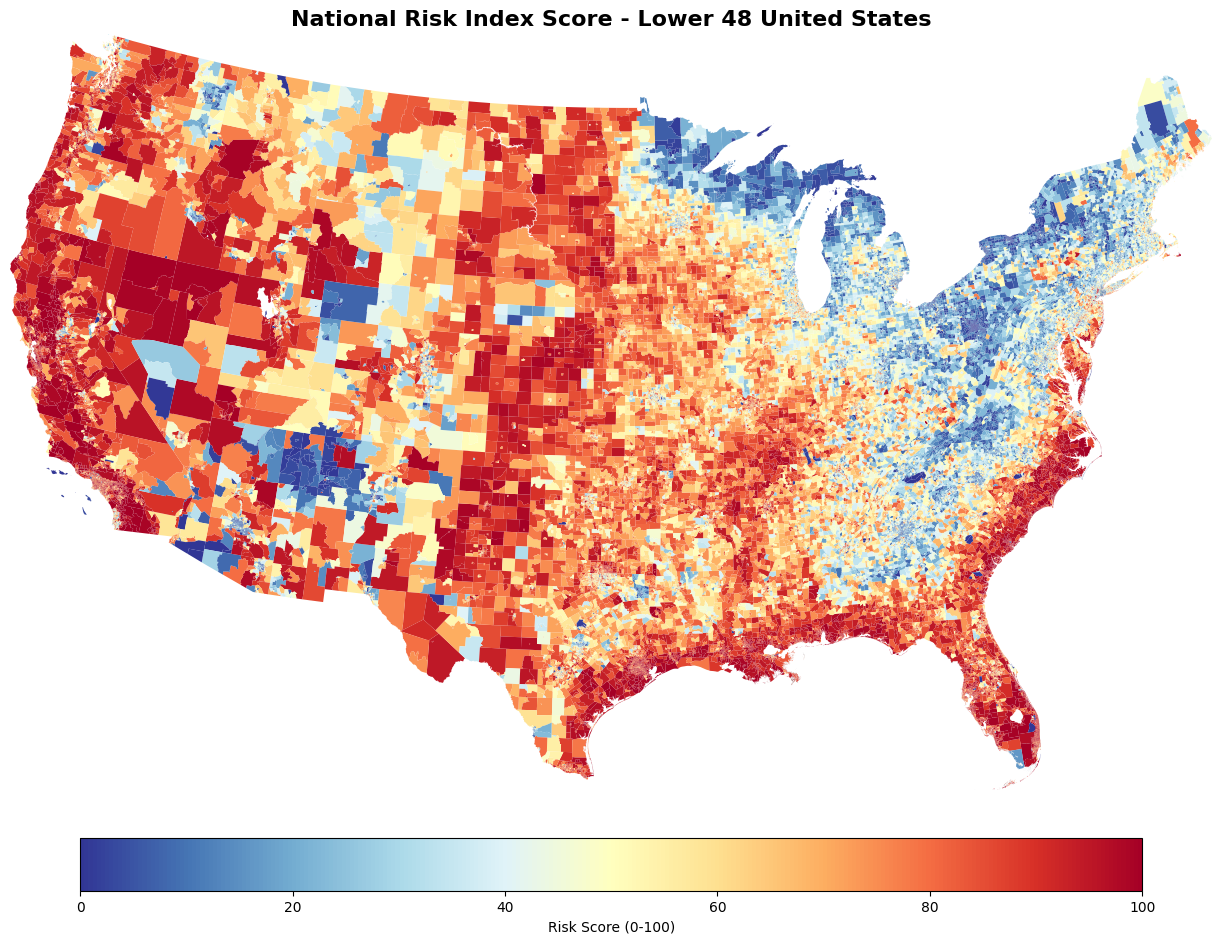

In [57]:
fig, ax=plt.subplots(1,1,figsize=(18,10))
tracts_lower48.plot(
    column="RISK_SCORE",
    cmap="RdYlBu_r",
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={"label":"Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds={"color": "lightgrey", "label":"No Data"},
)
minx, miny, maxx, maxy = tracts_lower48.total_bounds
padding = 0.5
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)
ax.set_title("National Risk Index Score - Lower 48 United States", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

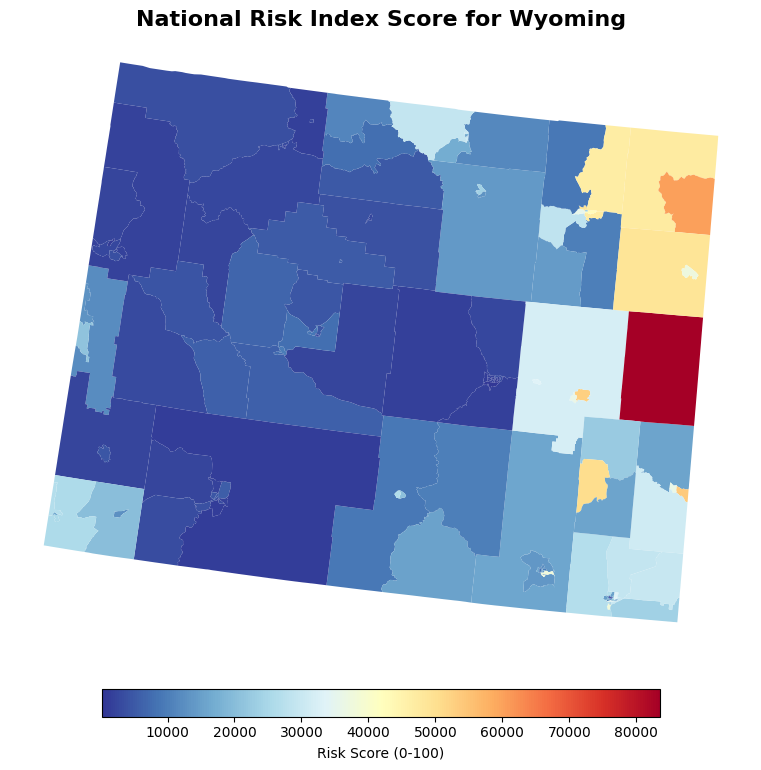

In [58]:
state_name = "Wyoming"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]
fig,ax = plt.subplots(1,1, figsize=(12,10))
state_map.plot(
    column = "WNTW_RISKV",
    cmap = "RdYlBu_r",
    aspect = 1,
    linewidth = 0.0,
    ax=ax,
    legend = True,
    legend_kwds = {"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds = {"color": "lightgrey", "label": "No Data"},
)

ax.set_title("National Risk Index Score for Wyoming", fontsize = 16, fontweight = "bold")
ax.set_axis_off()
plt.show()

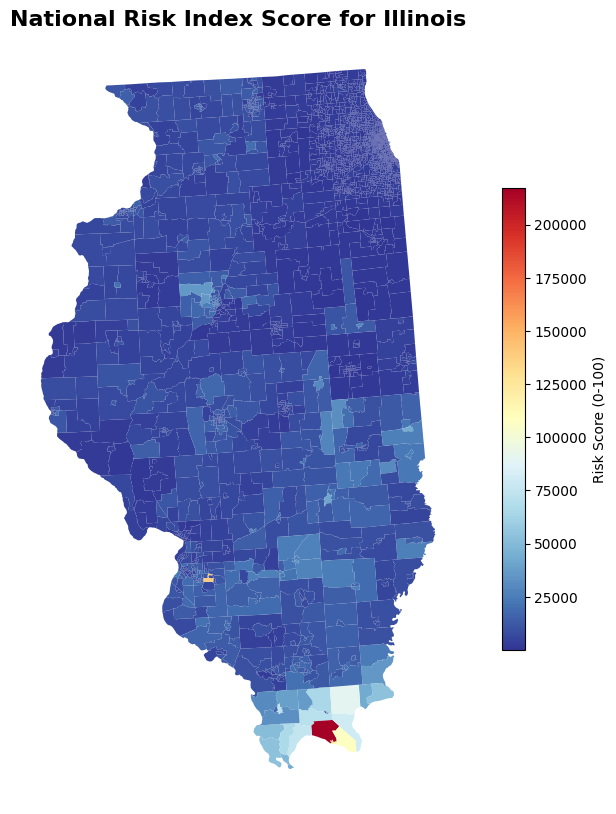

In [59]:
state_name = "Illinois"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]
fig,ax = plt.subplots(1,1, figsize=(12,10))
state_map.plot(
    column = "WNTW_RISKV",
    cmap = "RdYlBu_r",
    aspect = 1,
    linewidth = 0.0,
    ax=ax,
    legend = True,
    legend_kwds = {"label": "Risk Score (0-100)", "orientation": "vertical", "shrink": 0.6, "pad": 0.05},
    missing_kwds = {"color": "lightgrey", "label": "No Data"},
)

ax.set_title("National Risk Index Score for Illinois", fontsize = 16, fontweight = "bold")
ax.set_axis_off()
plt.show()

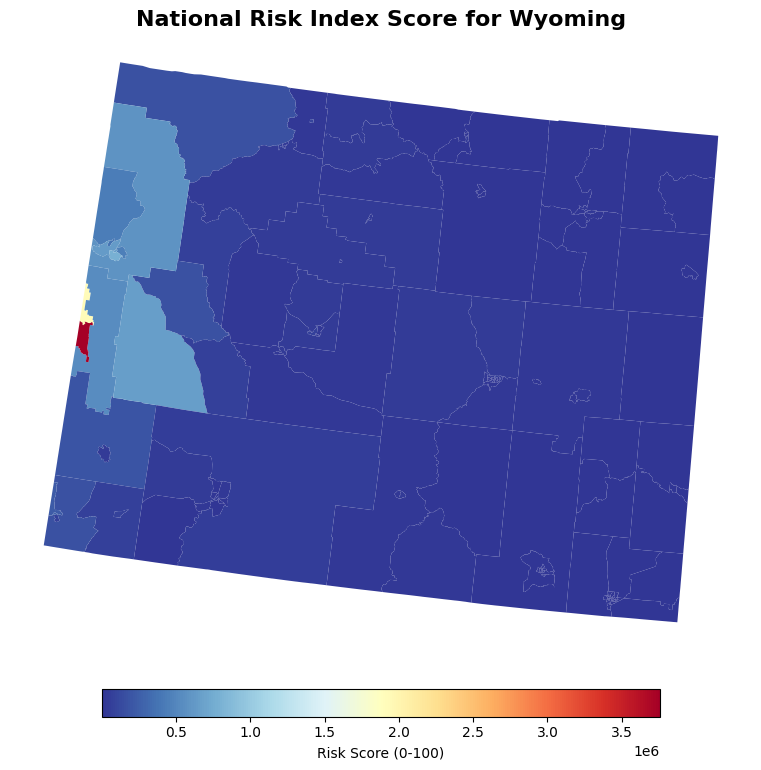

In [60]:
state_name = "Wyoming"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]
fig,ax = plt.subplots(1,1, figsize=(12,10))
state_map.plot(
    column = "ERQK_RISKV",
    cmap = "RdYlBu_r",
    aspect = 1,
    linewidth = 0.0,
    ax=ax,
    legend = True,
    legend_kwds = {"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds = {"color": "lightgrey", "label": "No Data"},
)

ax.set_title("National Risk Index Score for Wyoming", fontsize = 16, fontweight = "bold")
ax.set_axis_off()
plt.show()

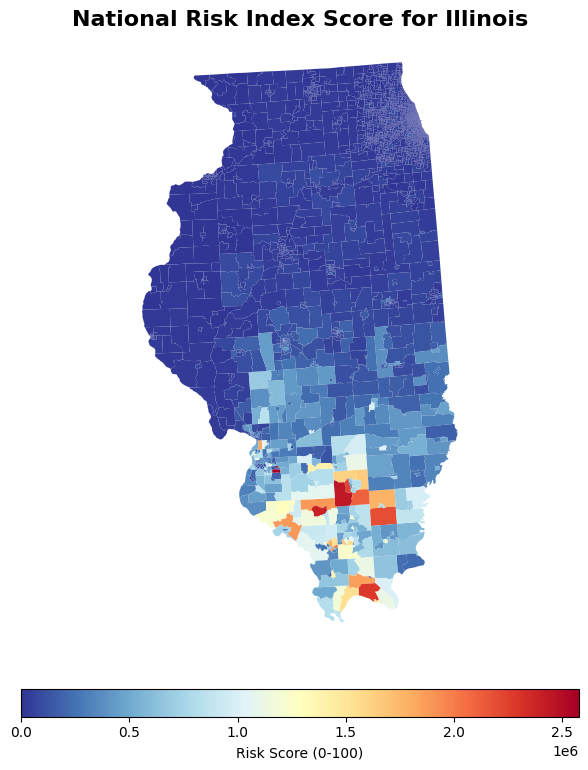

In [61]:
state_name = "Illinois"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]
fig,ax = plt.subplots(1,1, figsize=(12,10))
state_map.plot(
    column = "ERQK_RISKV",
    cmap = "RdYlBu_r",
    aspect = 1,
    linewidth = 0.0,
    ax=ax,
    legend = True,
    legend_kwds = {"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds = {"color": "lightgrey", "label": "No Data"},
)

ax.set_title("National Risk Index Score for Illinois", fontsize = 16, fontweight = "bold")
ax.set_axis_off()
plt.show()